# TITANIC SURVIVAL

this project is analyze the classic titanic data from kaggle

## Import the Library

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('C:\\Users\\Renitia\\OneDrive\\Desktop\\Porto\\Portfolio\\data\\Titanic_train.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## About Dataset

 The Titanic_train.csv file includes a target column called Survived
 - a passenger survived (1) 
 - did not survive (0)

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


 The Titanic_train.csv file includes detailed information for 891 passengers 

In [75]:
df["Cabin"].isnull().sum()

np.int64(687)

In [76]:
df["Age"].isnull().sum()

np.int64(177)

In [77]:
df["Embarked"].isnull().sum()

np.int64(2)

 ## Missing Value

 there are 3 column with missing value:
 - Age (687)
 - Cabin (177)
 - Embarked (2), this easily could be ignore because it has only 2 missing.

 ### 1. Age (687)


In [87]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


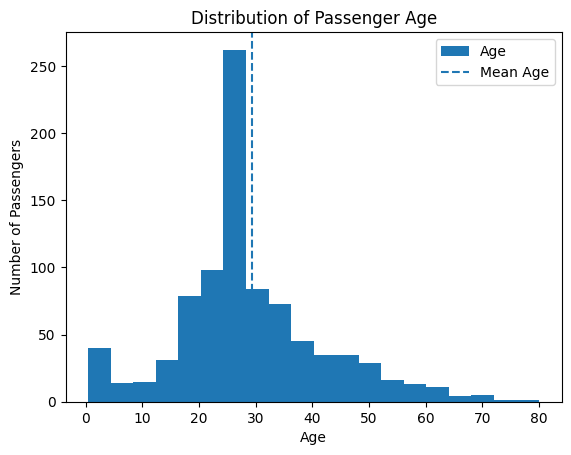

In [86]:
df["Age"].plot(kind="hist", bins=20)

plt.axvline(
    df["Age"].mean(),
    linestyle="--",
    label="Mean Age"
)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()

plt.show()

### 2. Cabin Missing (687)

In [78]:
df["Cabin_missing"] = df["Cabin"].isnull()

pd.crosstab(
    df["Pclass"],
    df["Cabin_missing"],
    normalize="index"
) * 100

Cabin_missing,False,True
Pclass,,
1,81.481481,18.518519
2,8.695652,91.304348
3,2.443992,97.556008


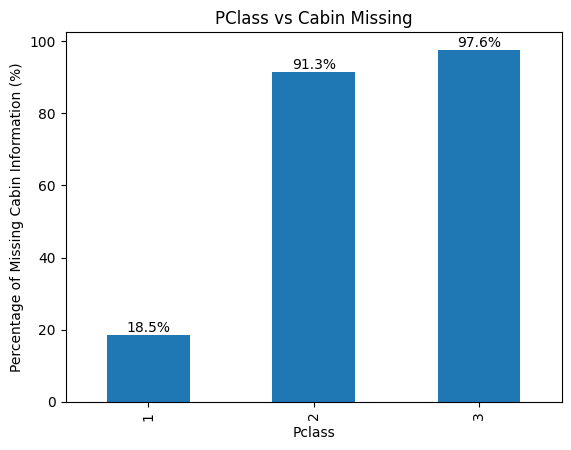

In [79]:
Pclass_vs_Cabin_Missing = (
    df.groupby("Pclass")["Cabin_missing"]
    .mean() * 100
)

ax = Pclass_vs_Cabin_Missing.plot(kind="bar")
plt.title("PClass vs Cabin Missing")
plt.ylabel("Percentage of Missing Cabin Information (%)")
for container in ax.containers: 
    ax.bar_label(container, fmt='%.1f%%')
plt.show()

Missing cabin values are disproportionately concentrated among  second and third-class passengers, suggesting that the missingness is related to passenger class rather than occurring completely at random.

## Missing Value Handling

The dataset contains missing values in Age, Cabin, and Embarked.

- Missing Embarked values were filled using the mode because only two records were missing.
- Missing Age values were filled using the median age to reduce the impact of outliers.
- Cabin contained more than 77% missing values. A binary indicator (Cabin_missing) was created to preserve potential information before dropping the original column.


In [80]:
# Embarked
df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

# Age
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

# Cabin indicator
df["Cabin_missing"] = df["Cabin"].isnull()

# Drop cabin
df = df.drop("Cabin", axis=1)

## Survival Analisist

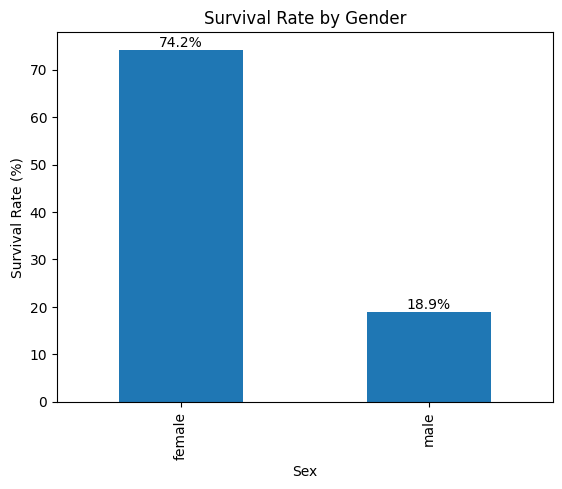

In [81]:
survival_by_gender = (
    df.groupby("Sex")["Survived"]
    .mean() * 100
)

ax = survival_by_gender.plot(kind="bar")
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate (%)")
for container in ax.containers: 
    ax.bar_label(container, fmt='%.1f%%')
plt.show()

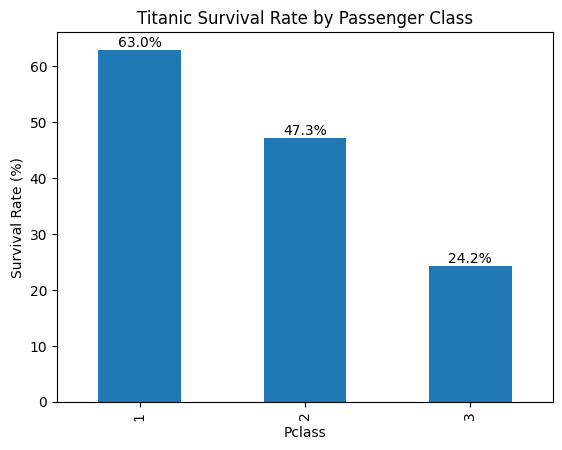

In [82]:
survival_by_class = (
    df.groupby("Pclass")["Survived"]
    .mean() * 100
)

ax = survival_by_class.plot(kind="bar")

plt.title("Titanic Survival Rate by Passenger Class")
plt.ylabel("Survival Rate (%)")
for container in ax.containers: 
    ax.bar_label(container, fmt='%.1f%%')
plt.show()

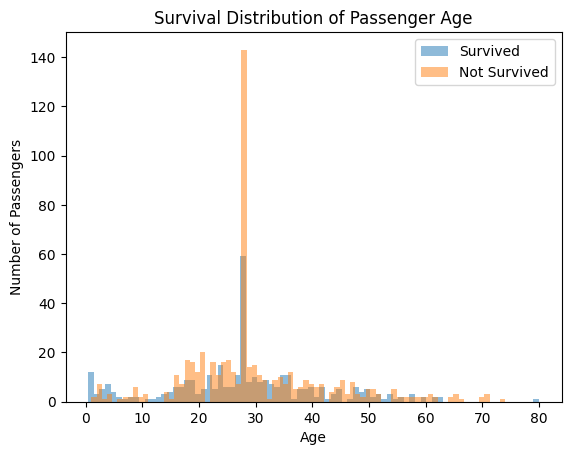

In [84]:
df[df["Survived"] == 1]["Age"].plot(
    kind="hist",
    bins=80,
    alpha=0.5,
    label="Survived"
)

df[df["Survived"] == 0]["Age"].plot(
    kind="hist",
    bins=80,
    alpha=0.5,
    label="Not Survived"
)

plt.title("Survival Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

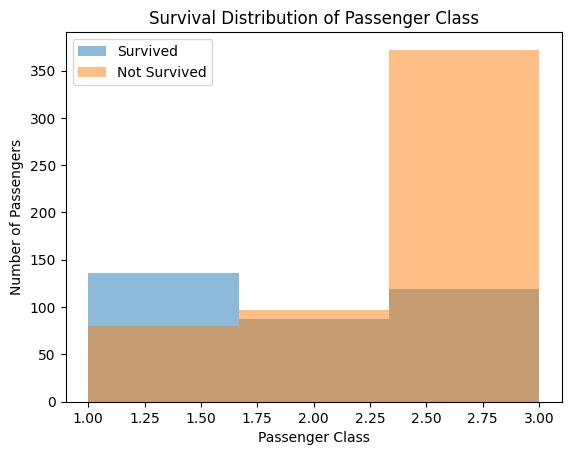

In [85]:
df[df["Survived"] == 1]["Pclass"].plot(
    kind="hist",
    bins=3,
    alpha=0.5,
    label="Survived"
)

df[df["Survived"] == 0]["Pclass"].plot(
    kind="hist",
    bins=3,
    alpha=0.5,
    label="Not Survived"
)

plt.title("Survival Distribution of Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()